# Acertijo del granjero y el bote (Representabilidad + BFS)

Este notebook resuelve el problema modelando cada estado como un vector binario:

**[G, L, Cb, Col]**

- `0` = orilla izquierda
- `1` = orilla derecha

Donde:
- `G`: Granjero
- `L`: Lobo
- `Cb`: Cabra
- `Col`: Col

## Idea de representabilidad

Esta codificación permite que la máquina evalúe reglas lógicas de forma directa:
- Estado prohibido si el lobo y la cabra quedan solos sin granjero.
- Estado prohibido si la cabra y la col quedan solas sin granjero.
- Movimiento válido: el granjero cruza solo o con un único elemento que esté en su misma orilla.

Luego, con **BFS (Búsqueda en Amplitud)**, se garantiza encontrar la secuencia óptima (mínimo número de cruces).

Secuencia optima de estados:
 1. [0, 0, 0, 0]
 2. [1, 0, 1, 0]
 3. [0, 0, 1, 0]
 4. [1, 1, 1, 0]
 5. [0, 1, 0, 0]
 6. [1, 1, 0, 1]
 7. [0, 1, 0, 1]
 8. [1, 1, 1, 1]

Movimientos:
 1. G cruza con Cb
 2. G cruza solo
 3. G cruza con L
 4. G cruza con Cb
 5. G cruza con Col
 6. G cruza solo
 7. G cruza con Cb

Total de cruces: 7


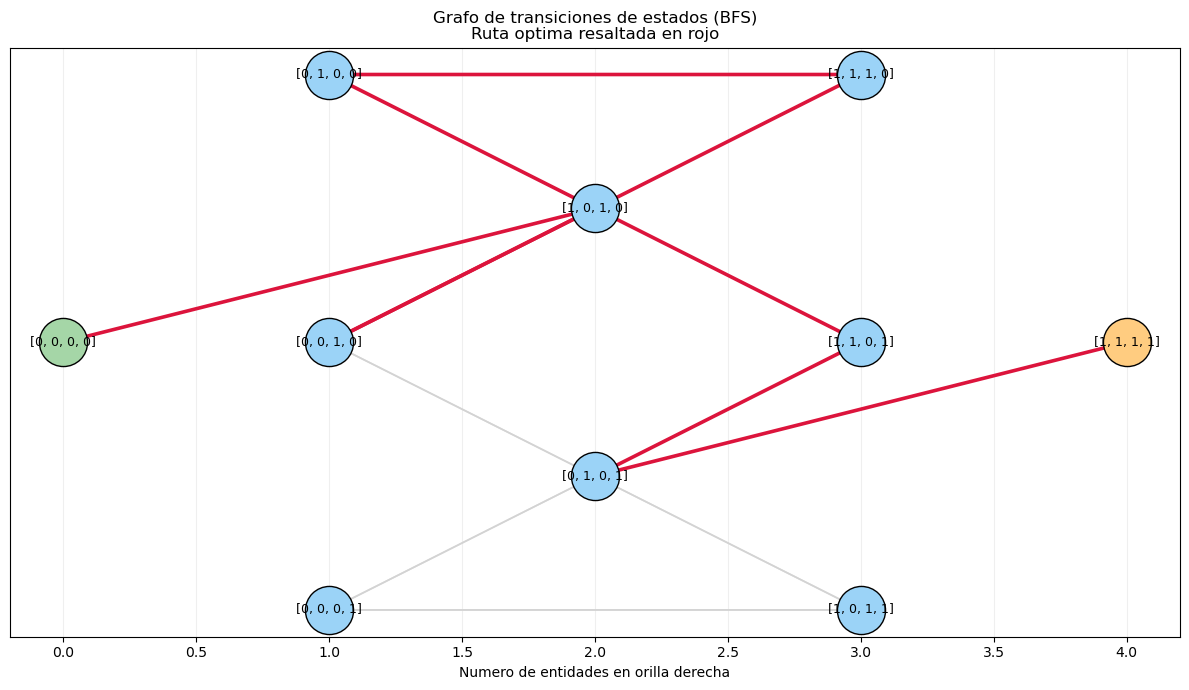

In [1]:
from collections import deque, defaultdict
import matplotlib.pyplot as plt

# ==========================================================
# 1) REPRESENTACION DEL ESTADO: [G, L, Cb, Col]
# ==========================================================
# Convencion:
#   0 = orilla izquierda
#   1 = orilla derecha
#
# Ejemplo: (0, 1, 0, 1)
#   G a la izquierda, L a la derecha, Cb a la izquierda, Col a la derecha.

START = (0, 0, 0, 0)
GOAL = (1, 1, 1, 1)


def es_estado_seguro(s):
    """Retorna True si el estado no viola las reglas del acertijo."""
    G, L, Cb, Col = s

    # Prohibido: Lobo con Cabra sin Granjero
    if L == Cb and G != L:
        return False

    # Prohibido: Cabra con Col sin Granjero
    if Cb == Col and G != Cb:
        return False

    return True


def vecinos_validos(s):
    """
    Genera estados alcanzables en un solo cruce:
    - El granjero siempre cruza de orilla.
    - Puede cruzar solo o con un unico acompanante que este en su misma orilla.
    """
    G, L, Cb, Col = s
    candidatos = []

    # Opcion 1: granjero cruza solo
    candidatos.append((1 - G, L, Cb, Col))

    # Opcion 2: granjero cruza con Lobo (si estan juntos)
    if L == G:
        candidatos.append((1 - G, 1 - L, Cb, Col))

    # Opcion 3: granjero cruza con Cabra (si estan juntos)
    if Cb == G:
        candidatos.append((1 - G, L, 1 - Cb, Col))

    # Opcion 4: granjero cruza con Col (si estan juntos)
    if Col == G:
        candidatos.append((1 - G, L, Cb, 1 - Col))

    # Filtrar solo estados seguros
    return [ns for ns in candidatos if es_estado_seguro(ns)]


def bfs_solucion(inicio, meta):
    """
    BFS sobre el espacio de estados.
    Devuelve:
    - path: ruta optima de estados
    - padres: para reconstruccion
    - edges: aristas exploradas (grafo de transiciones seguras)
    """
    q = deque([inicio])
    visited = {inicio}
    padres = {inicio: None}
    edges = []

    while q:
        actual = q.popleft()
        if actual == meta:
            break

        for nxt in vecinos_validos(actual):
            edges.append((actual, nxt))
            if nxt not in visited:
                visited.add(nxt)
                padres[nxt] = actual
                q.append(nxt)

    # Reconstruccion de ruta optima
    if meta not in padres:
        return None, padres, edges

    path = []
    cur = meta
    while cur is not None:
        path.append(cur)
        cur = padres[cur]
    path.reverse()
    return path, padres, edges


def etiqueta_estado(s):
    """Etiqueta corta para mostrar estado como vector [G,L,Cb,Col]."""
    return f"[{s[0]}, {s[1]}, {s[2]}, {s[3]}]"


def explicar_movimiento(a, b):
    """Describe que cruza entre dos estados consecutivos."""
    cambios = [i for i in range(4) if a[i] != b[i]]
    nombres = ["G", "L", "Cb", "Col"]

    if cambios == [0]:
        return "G cruza solo"
    if 0 in cambios and len(cambios) == 2:
        otro = [i for i in cambios if i != 0][0]
        return f"G cruza con {nombres[otro]}"
    return "Movimiento"


def layout_por_capas(nodos):
    """
    Posiciona nodos por cantidad de unos (entidades en orilla derecha)
    para visualizar progreso hacia la meta.
    """
    capas = defaultdict(list)
    for n in nodos:
        capas[sum(n)].append(n)

    pos = {}
    for capa, lista in capas.items():
        lista_ordenada = sorted(lista)
        k = len(lista_ordenada)
        for idx, nodo in enumerate(lista_ordenada):
            y = idx - (k - 1) / 2
            x = capa
            pos[nodo] = (x, y)
    return pos


def dibujar_grafo_transiciones(edges, path):
    """Dibuja el grafo de transiciones y resalta la ruta solucion optima."""
    nodos = set()
    for u, v in edges:
        nodos.add(u)
        nodos.add(v)
    for n in path:
        nodos.add(n)

    pos = layout_por_capas(nodos)

    plt.figure(figsize=(12, 7))

    # Aristas exploradas (gris)
    for u, v in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        plt.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", color="lightgray", lw=1.2, alpha=0.9)
        )

    # Aristas de la solucion (rojo)
    solucion_edges = list(zip(path[:-1], path[1:]))
    for u, v in solucion_edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        plt.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", color="crimson", lw=2.6)
        )

    # Nodos
    for n in nodos:
        x, y = pos[n]
        color = "#9bd3f7"
        if n == START:
            color = "#a5d6a7"  # verde inicio
        if n == GOAL:
            color = "#ffcc80"  # naranja meta
        plt.scatter(x, y, s=1200, c=color, edgecolors="black", zorder=3)
        plt.text(x, y, etiqueta_estado(n), ha="center", va="center", fontsize=9, zorder=4)

    plt.title("Grafo de transiciones de estados (BFS)\nRuta optima resaltada en rojo")
    plt.xlabel("Numero de entidades en orilla derecha")
    plt.yticks([])
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 2) EJECUCION: BFS OPTIMO
# ==========================================================
path, padres, edges = bfs_solucion(START, GOAL)

if path is None:
    print("No se encontro solucion.")
else:
    print("Secuencia optima de estados:")
    for i, s in enumerate(path, start=1):
        print(f"{i:2d}. {etiqueta_estado(s)}")

    print("\nMovimientos:")
    for i, (a, b) in enumerate(zip(path[:-1], path[1:]), start=1):
        print(f"{i:2d}. {explicar_movimiento(a, b)}")

    print(f"\nTotal de cruces: {len(path) - 1}")

    # Visualizacion del grafo de transiciones
    dibujar_grafo_transiciones(edges, path)
